# 1️⃣ Data Loading & Exploration

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("srisyra02/diabetes-risk-prediction-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'diabetes-risk-prediction-dataset' dataset.
Path to dataset files: /kaggle/input/diabetes-risk-prediction-dataset


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)
from sklearn.preprocessing import StandardScaler
import joblib

In [ ]:
print("Files in Dataset directory: ")
for file in os.listdir(path):
    print(file)

Files in Dataset directory: 
diabetes_risk_prediction_dataset.csv


In [ ]:
df = pd.read_csv(os.path.join(path, "diabetes_risk_prediction_dataset.csv"))
df.head()

,Patient_ID,Age,Gender,Country,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,...,PCOS,Medication_Adherence,Work_Type,Residence_Type,Daily_Water_Intake_L,Diabetes_Risk_Score,AI_Health_Recommendation,Doctor_Consultation_Needed,Diabetes_Risk,BMI_CATEGORY
0,1,32.0,Male,Mexico,182.1,65.8,19.8,71.2,88.4,10.4,...,No,Good,Retired,Rural,4.4,60,Healthy Diet Plan,Yes,Moderate,Normal
1,2,42.0,Other,Saudi Arabia,148.5,101.2,45.9,121.8,247.3,11.3,...,Yes,Average,Government,Rural,2.1,99,Begin Diabetes Management Plan,Yes,High,Obese
2,3,89.0,Other,Argentina,158.1,NaN,37.9,131.8,141.9,6.3,...,No,Average,Government,Urban,2.8,80,Strict Blood Sugar Monitoring,Yes,High,Obese
3,4,87.0,Other,United States,190.9,95.9,26.3,99.1,90.1,7.4,...,No,Average,Business,Rural,1.5,82,Begin Diabetes Management Plan,Yes,High,Overweight
4,5,27.0,Other,Australia,156.9,101.9,41.4,77.1,93.8,12.0,...,Yes,Poor,Private,Rural,1.6,93,Begin Diabetes Management Plan,Yes,High,Obese


In [ ]:
df.shape

(50000, 42)

In [ ]:
print(df.isnull().sum())

Patient_ID                       0
Age                            497
Gender                           0
Country                          0
Height_cm                     2945
Weight_kg                     2962
BMI                              0
Waist_Circumference_cm           0
Blood_Glucose                  959
HbA1c                         1974
Fasting_Blood_Sugar              0
Insulin_Level                    0
Blood_Pressure_Systolic          0
Blood_Pressure_Diastolic         0
Total_Cholesterol             1000
HDL                           1000
LDL                           1000
Triglycerides                 1000
Heart_Rate                       0
Physical_Activity_Level        500
Exercise_Hours_Per_Week       1992
Daily_Walking_Minutes         1964
Diet_Quality                     0
Sugar_Intake_Level               0
Sleep_Hours                   2017
Stress_Level                     0
Smoking_Status                   0
Alcohol_Consumption              0
Family_History_Diabe

In [ ]:
df.describe()

,Patient_ID,Age,Height_cm,Weight_kg,BMI,Waist_Circumference_cm,Blood_Glucose,HbA1c,Fasting_Blood_Sugar,Insulin_Level,...,Total_Cholesterol,HDL,LDL,Triglycerides,Heart_Rate,Exercise_Hours_Per_Week,Daily_Walking_Minutes,Sleep_Hours,Daily_Water_Intake_L,Diabetes_Risk_Score
count,50000.000000,49503.000000,47055.000000,47038.000000,50000.000000,50000.000000,49041.000000,48026.000000,50000.000000,50000.000000,...,49000.000000,49000.000000,49000.000000,49000.000000,50000.000000,48008.000000,48036.000000,47983.000000,50000.000000,50000.000000
mean,25000.500000,53.871099,170.018814,87.457003,30.924056,99.960790,159.905245,8.488061,142.607294,23.476724,...,220.168635,57.371731,135.014524,229.543259,85.124260,5.017460,89.933442,6.500917,2.998842,74.043920
std,14433.901067,21.130148,14.457787,24.500358,10.290091,23.086579,52.040575,2.313758,44.681799,12.403841,...,57.793626,18.720696,49.135613,98.234911,20.390334,2.875922,52.034642,2.027793,1.152273,15.598327
min,1.000000,18.000000,145.000000,45.000000,11.900000,60.000000,70.000000,4.500000,65.000000,2.000000,...,120.000000,25.000000,50.000000,60.000000,50.000000,0.000000,0.000000,3.000000,1.000000,13.000000
25%,12500.750000,35.000000,157.600000,66.300000,22.700000,80.000000,114.700000,6.500000,103.900000,12.800000,...,169.800000,41.300000,92.500000,144.700000,68.000000,2.500000,44.900000,4.700000,2.000000,64.000000
50%,25000.500000,54.000000,170.000000,87.300000,30.000000,99.800000,159.900000,8.500000,142.600000,23.400000,...,220.400000,57.300000,135.100000,229.500000,85.000000,5.000000,89.800000,6.500000,3.000000,75.000000
75%,37500.250000,72.000000,182.600000,108.600000,37.800000,119.900000,205.100000,10.500000,181.500000,34.300000,...,270.500000,73.600000,177.700000,314.600000,103.000000,7.500000,135.200000,8.300000,4.000000,86.000000
max,50000.000000,90.000000,195.000000,130.000000,61.700000,140.000000,250.000000,12.500000,220.000000,45.000000,...,320.000000,90.000000,220.000000,400.000000,120.000000,10.000000,180.000000,10.000000,5.000000,100.000000


In [ ]:
print("All Columns: \n",df.columns)
print("="*60)
print("Object Columns: \n",df.select_dtypes(include = "object").columns)
print("="*60)
print("Numerical Columns: \n",df.select_dtypes(exclude = "object").columns)

All Columns: 
 Index(['Patient_ID', 'Age', 'Gender', 'Country', 'Height_cm', 'Weight_kg',
       'BMI', 'Waist_Circumference_cm', 'Blood_Glucose', 'HbA1c',
       'Fasting_Blood_Sugar', 'Insulin_Level', 'Blood_Pressure_Systolic',
       'Blood_Pressure_Diastolic', 'Total_Cholesterol', 'HDL', 'LDL',
       'Triglycerides', 'Heart_Rate', 'Physical_Activity_Level',
       'Exercise_Hours_Per_Week', 'Daily_Walking_Minutes', 'Diet_Quality',
       'Sugar_Intake_Level', 'Sleep_Hours', 'Stress_Level', 'Smoking_Status',
       'Alcohol_Consumption', 'Family_History_Diabetes', 'Hypertension',
       'Heart_Disease', 'Fatty_Liver', 'PCOS', 'Medication_Adherence',
       'Work_Type', 'Residence_Type', 'Daily_Water_Intake_L',
       'Diabetes_Risk_Score', 'AI_Health_Recommendation',
       'Doctor_Consultation_Needed', 'Diabetes_Risk', 'BMI_CATEGORY'],
      dtype='object')
Object Columns: 
 Index(['Gender', 'Country', 'Physical_Activity_Level', 'Diet_Quality',
       'Sugar_Intake_Level', 'Stress

In [ ]:
df.drop(["Patient_ID","Diabetes_Risk_Score","AI_Health_Recommendation","Doctor_Consultation_Needed","Medication_Adherence"], axis=1, inplace = True)

In [ ]:
df= df.replace(" ",np.nan)

In [ ]:
for i in df.columns:
  if df[i].dtypes == "object":
    df[i] = df[i].fillna(df[i].mode()[0])
  else:
    df[i] = df[i].fillna(df[i].median())

**converted categories to numeric**

In [ ]:
df["BMI_CATEGORY"] = df["BMI_CATEGORY"].map({"Underweight":0, "Normal":1, "Overweight":2, "Obese":3})
df["Diabetes_Risk"] = df["Diabetes_Risk"].map({"Low":0, "Moderate":1, "High":2})
df["Diet_Quality"] = df["Diet_Quality"].map({"Poor":0, "Average":1, "Healthy":2})
df["Residence_Type"] = df["Residence_Type"].map({"Rural":0, "Urban":1})

In [ ]:
for i in df.select_dtypes (include = 'object').columns:
    print(i, df[i].nunique())

Gender 3
Country 25
Physical_Activity_Level 3
Sugar_Intake_Level 3
Stress_Level 3
Smoking_Status 3
Alcohol_Consumption 3
Family_History_Diabetes 2
Hypertension 2
Heart_Disease 2
Fatty_Liver 2
PCOS 2
Work_Type 5


In [ ]:
object_score =[]
for i in df.select_dtypes(include = "object").columns:
  if df[i].nunique() >2:
    object_score.append(i)

df = pd.get_dummies(df, columns = object_score, drop_first=True, dtype=float)

In [ ]:
lowOb_score = []
for i in df.select_dtypes(include = "object").columns:
  if df[i].nunique() == 2:
    lowOb_score.append(i)

for i in lowOb_score:
  df[i] = df[i].map({"Yes":1, "No":0})

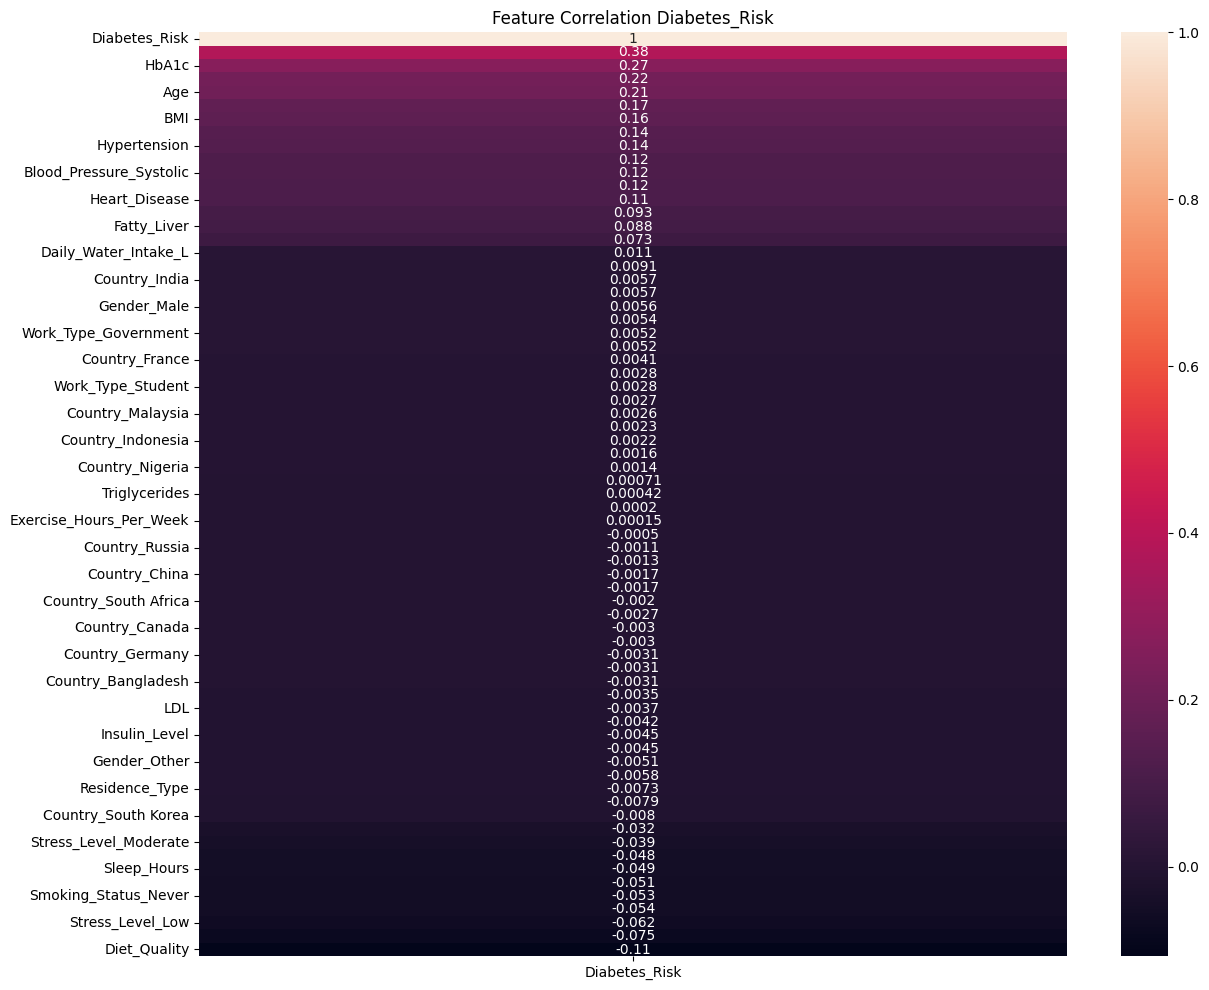

In [ ]:
plt.figure(figsize=(14,12))
sns.heatmap(df.corr()["Diabetes_Risk"].sort_values(ascending=False).to_frame(), annot=True)
plt.title("Feature Correlation Diabetes_Risk")
plt.show()

# 2️⃣ Data Preprocessing

In [ ]:
X = df.drop("Diabetes_Risk", axis=1)
y = df["Diabetes_Risk"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
for i in df.columns:
  if " " in i:
   print(i)

Country_Saudi Arabia
Country_South Africa
Country_South Korea
Country_United Kingdom
Country_United States


In [ ]:
X.isnull().sum()[X.isnull().sum() > 0]

,0


# 3️⃣ Model Training

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth = 10, min_samples_split=2)
}

for name, model in models.items():
  model.fit(X_train_scaled, y_train)
  y_pred = model.predict(X_test_scaled)
  y_proba = model.predict_proba(X_test_scaled)

# Model Evaluation

In [ ]:
result = []
roc_data = {}

for name, model in models.items():
  Acc = accuracy_score(y_test, y_pred)
  pcs = precision_score(y_test, y_pred, average='weighted')
  rcs = recall_score(y_test, y_pred, average='weighted')
  f1s = f1_score(y_test, y_pred, average='weighted')
  roc = roc_auc_score(y_test, y_proba, multi_class='ovr')

  result.append({
      "Model": name,
      "Accuracy": Acc,
      "Precision": pcs,
      "Recall": rcs,
      "F1_score": f1s,
      "roc_auc_score": roc
  })

  print("="*60)
  print(name)
  print("="*60)
  print("Accuracy: ", Acc)
  print("Precision: ", pcs)
  print("Recall: ", rcs)
  print("F1_score: ", f1s)
  print("roc_auc_score: ", roc)


Logistic Regression
Accuracy:  0.8623
Precision:  0.8596559825452347
Recall:  0.8623
F1_score:  0.845435725272084
roc_auc_score:  0.9660611363682406
Random Forest
Accuracy:  0.8623
Precision:  0.8596559825452347
Recall:  0.8623
F1_score:  0.845435725272084
roc_auc_score:  0.9660611363682406


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
comp_model = pd.DataFrame(result).sort_values(by = "roc_auc_score", ascending = False)
print("\n=== Model Comparison (sorted by ROC AUC) ===")
comp_model



=== Model Comparison (sorted by ROC AUC) ===


,Model,Accuracy,Precision,Recall,F1_score,roc_auc_score
0,Logistic Regression,0.8623,0.859656,0.8623,0.845436,0.966061
1,Random Forest,0.8623,0.859656,0.8623,0.845436,0.966061


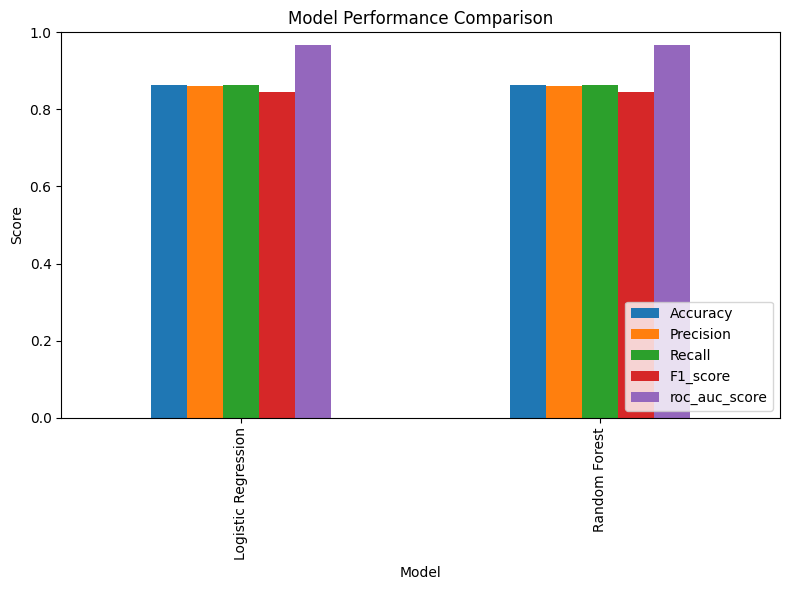

In [ ]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1_score", "roc_auc_score"]
plot_df = comp_model.set_index("Model")[metrics_to_plot]

plot_df.plot(kind="bar", figsize=(8, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("model_metrics_comparison.png", dpi=150)
plt.show()

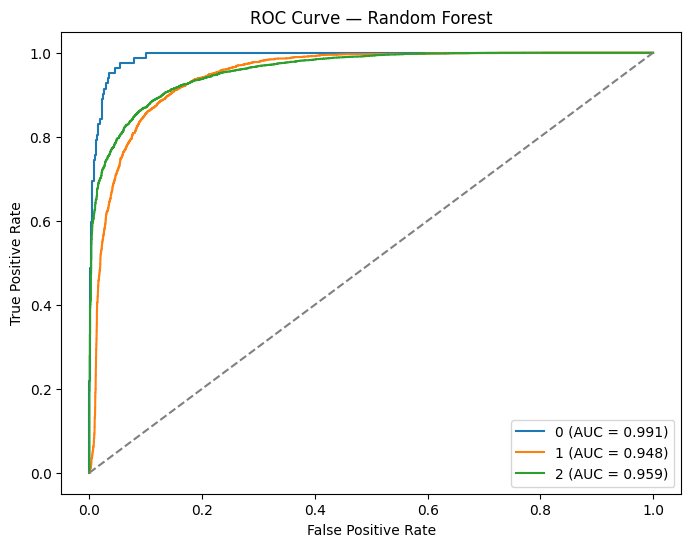

In [ ]:
from sklearn.preprocessing import label_binarize

classes = model.classes_
y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba[:, i])
    auc_score = roc_auc_score(y_test_bin[:, i], y_proba[:, i])
    plt.plot(fpr, tpr, label=f"{cls} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curve — {name}")
plt.legend()
plt.show()

# Best Model

In [ ]:
best_model_name = comp_model.iloc[0]["Model"]
best_model = models[best_model_name]

print("Best Model: ", best_model)

joblib.dump(best_model, "diabetes_model.pkl")
joblib.dump(scaler, "diabetes_scaler.pkl")
print("Saved best model to diabetes_model.pkl and scaler to diabetes_scaler.pkl")


Best Model:  LogisticRegression()
Saved best model to diabetes_model.pkl and scaler to diabetes_scaler.pkl
